In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the signals
signal_1 = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 0.8, 0.6, 0.4, 0.2])  # Reference signal
signal_2 = np.array([0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 0.9, 0.7, 0.5, 0.4, 0.3, 0.2])  # Test signal




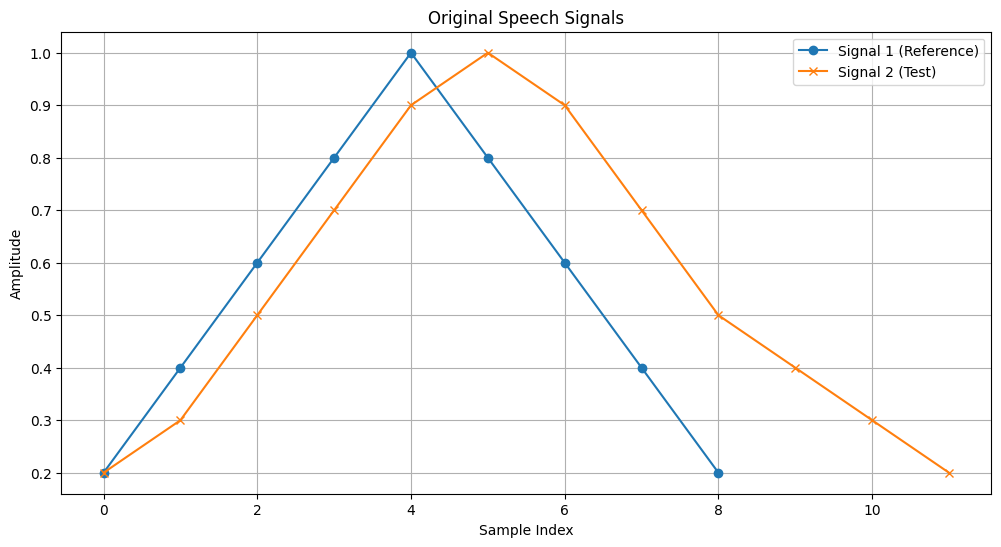

In [2]:
# (a) Plot both speech signals
plt.figure(figsize=(12, 6))
plt.plot(signal_1, marker='o', label="Signal 1 (Reference)")
plt.plot(signal_2, marker='x', label="Signal 2 (Test)")
plt.title("Original Speech Signals")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()



In [3]:
# (b) Linear Time Normalization: Interpolate Signal 2 to match the length of Signal 1
normalized_signal_2 = np.interp(
    np.linspace(0, len(signal_2) - 1, len(signal_1)),
    np.arange(len(signal_2)),
    signal_2
)

In [4]:
# (c) Compute alignment between Signal 1 and the normalized Signal 2
alignment = [(i, np.argmin(np.abs(normalized_signal_2 - val))) for i, val in enumerate(signal_1)]

# Display results
print("Normalized Signal 2:", normalized_signal_2)
print("Alignment:", alignment)

Normalized Signal 2: [0.2    0.375  0.65   0.9125 0.95   0.725  0.475  0.3375 0.2   ]
Alignment: [(0, 0), (1, 1), (2, 2), (3, 5), (4, 4), (5, 5), (6, 2), (7, 1), (8, 0)]


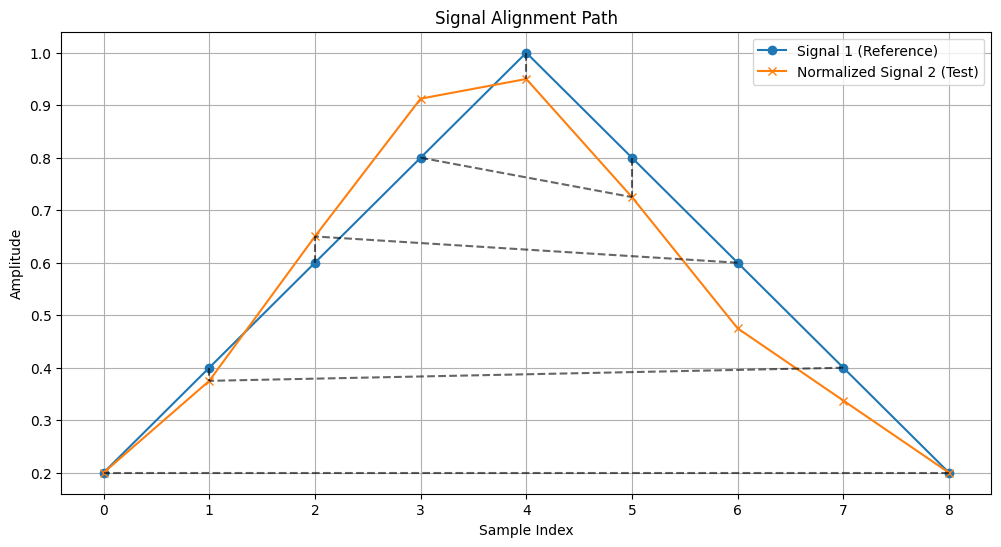

In [5]:
# (d) Plot the alignment path
plt.figure(figsize=(12, 6))
plt.plot(signal_1, marker='o', label="Signal 1 (Reference)")
plt.plot(normalized_signal_2, marker='x', label="Normalized Signal 2 (Test)")
for i, j in alignment:
    plt.plot([i, j], [signal_1[i], normalized_signal_2[j]], 'k--', alpha=0.6)  # Alignment path
plt.title("Signal Alignment Path")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

### Discussion of Linear Time Normalization (LTN) Alignment

Linear Time Normalization adjusts the time scale of one signal (in this case, Signal 2) to match the length of another (Signal 1). This allows us to compare signals of different durations directly.

---

#### **Inference from the Second Plot**

1. **Interpolation Process**:
   - The plot shows that Signal 2 was resampled using interpolation to reduce its 12 original samples to match the 9 samples of Signal 1.
   - The amplitude values at intermediate positions in Signal 2 were recalculated to align with the corresponding time steps in Signal 1.

2. **Amplitude Patterns**:
   - The general shape and amplitude variation of Signal 2 were preserved during normalization, although some details (like peaks and valleys) were slightly smoothed due to interpolation.

3. **Alignment Path**:
   - The dashed lines in the plot represent how each sample in Signal 1 corresponds to a sample in the normalized Signal 2.
   - For instance:
     - Sample 0 of Signal 1 aligns with sample 0 of normalized Signal 2.
     - Sample 3 of Signal 1 aligns with sample 5 of normalized Signal 2, highlighting how slower speech in Signal 2 is compressed to match the faster-paced Signal 1.

4. **Observations from Alignment**:
   - Samples with similar amplitudes in both signals align closely (e.g., samples 0, 1, and 2).
   - For regions where Signal 2 has additional details due to its slower pace (e.g., between indices 4 and 8 in Signal 2), the interpolation process compresses these details.

---

#### **Insights into Linear Time Normalization's Role**:
1. **Purpose**:
   - The method ensures both signals are comparable in length, enabling meaningful alignment and similarity measurement.

2. **Efficiency**:
   - LTN is computationally inexpensive and works well for signals with predictable and uniform temporal scaling.

3. **Limitations**:
   - LTN assumes uniform stretching/compression across the entire signal, which may not be realistic for more complex speech variations where some parts are stretched more than others.

---

#### **Applications of LTN in Speech Processing**:
- **Template Matching**: Comparing a test utterance with a reference signal for speaker verification or word recognition.
- **Preprocessing Step**: Aligning signals for more advanced techniques like Dynamic Time Warping (DTW), which can handle nonlinear stretching.

In this example, LTN effectively aligns the signals, showing the broader potential for aligning speech data with simple and efficient methods.